# CodeAlpha Data Analytics Internship — Task 1: Web Scraping

## Objective

The objective of this project is to extract structured data from a website using Python. The collected information will be organized into a Pandas DataFrame and saved as a CSV file for further analysis.

## Tools and Libraries

* **Requests:** To send HTTP requests and retrieve webpage content.
* **BeautifulSoup:** To parse HTML and extract information from webpage elements.
* **Pandas:** To organize the extracted data into a table and export it to CSV.

## Methodology

1. Access a practice bookstore website.
2. Retrieve and parse its HTML content.
3. Extract book titles, prices, ratings and availability.
4. organize the extracted information into a structured dataset.
5. Save the dataset as a CSV file and examine the results.

## Expected Outcome

A structured dataset of book information that can be reused for data analysis and visualization.



In [4]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
import time

print("All libraries are ready!")

All libraries are ready!


In [5]:
# Website used for practice web scraping
base_url = "https://books.toscrape.com/catalogue/page-{}.html"

all_books = []
max_pages = 5

for page_num in range(1, max_pages + 1):

    url = base_url.format(page_num)
    response = requests.get(url, timeout=20)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")
    books = soup.select("article.product_pod")

    for book in books:
        title_tag = book.select_one("h3 a")
        price_tag = book.select_one(".price_color")
        availability_tag = book.select_one(".availability")
        rating_tag = book.select_one(".star-rating")

        title = title_tag["title"] if title_tag else "Unknown"
        price = price_tag.get_text(strip=True) if price_tag else "Unknown"
        availability = (
            availability_tag.get_text(" ", strip=True)
            if availability_tag else "Unknown"
        )

        rating_classes = (
            rating_tag.get("class", []) if rating_tag else []
        )
        rating = next(
            (word for word in rating_classes if word != "star-rating"),
            "Unknown"
        )

        all_books.append({
            "Title": title,
            "Price": price,
            "Rating": rating,
            "Availability": availability
        })

    print(f"Page {page_num} scraped: {len(books)} books found.")
    time.sleep(0.5)

print("\nScraping completed!")
print("Total books collected:", len(all_books))

Page 1 scraped: 20 books found.
Page 2 scraped: 20 books found.
Page 3 scraped: 20 books found.
Page 4 scraped: 20 books found.
Page 5 scraped: 20 books found.

Scraping completed!
Total books collected: 100


In [6]:
df = pd.DataFrame(all_books)
print("Dataset Shape:",df.shape)
print("\nFirst Five Records:")
display(df.head())

Dataset Shape: (100, 4)

First Five Records:


,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [7]:
print("Columns Nmaes:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.to_csv("books_dataset.csv",index=False)
print("\nDataset saved successfully.'")


Columns Nmaes:
['Title', 'Price', 'Rating', 'Availability']

Missing Values:
Title           0
Price           0
Rating          0
Availability    0
dtype: int64

Duplicate Rows: 0

Dataset saved successfully.'


In [8]:
from google.colab import files
files.download('books_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Results and Conclusion

The project demonstrates how Python can be used to collect structured information from a website. BeautifulSoup was used to extract book titles, prices, ratings and availability, while Pandas was used to organize the collected information into a tabular dataset.

The extracted data was saved in CSV format for further analysis. This project provided practical experience with HTML parsing, web scraping, data collection and dataset creation.

The final observations should be updated according to the actual output obtained during execution.



In [9]:
# Create a copy for cleaning
clean_df = df.copy()

# Remove the currency symbol and convert prices to numeric values
clean_df["Price"] = (
    clean_df["Price"]
    .str.replace("£", "", regex=False)
    .str.replace("Â", "", regex=False)
    .astype(float)
)

# Check the cleaned dataset
print("Dataset shape:", clean_df.shape)
print("\nData types:")
print(clean_df.dtypes)

display(clean_df.head())

Dataset shape: (100, 4)

Data types:
Title            object
Price           float64
Rating           object
Availability     object
dtype: object


,Title,Price,Rating,Availability
0,A Light in the Attic,51.77,Three,In stock
1,Tipping the Velvet,53.74,One,In stock
2,Soumission,50.10,One,In stock
3,Sharp Objects,47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock


In [10]:
print("Total books:", len(clean_df))
print("Unique book titles:", clean_df["Title"].nunique())

print("\nAverage book price: £", round(clean_df["Price"].mean(), 2))
print("Cheapest book price: £", round(clean_df["Price"].min(), 2))
print("Most expensive book price: £", round(clean_df["Price"].max(), 2))

print("\nBook rating counts:")
print(clean_df["Rating"].value_counts())

print("\nAvailability counts:")
print(clean_df["Availability"].value_counts())

Total books: 100
Unique book titles: 100

Average book price: £ 34.56
Cheapest book price: £ 10.16
Most expensive book price: £ 58.11

Book rating counts:
Rating
Three    22
One      22
Five     19
Two      19
Four     18
Name: count, dtype: int64

Availability counts:
Availability
In stock    100
Name: count, dtype: int64


In [11]:
clean_df.to_csv("books_dataset_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [12]:
from google.colab import files
files.download("books_dataset_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

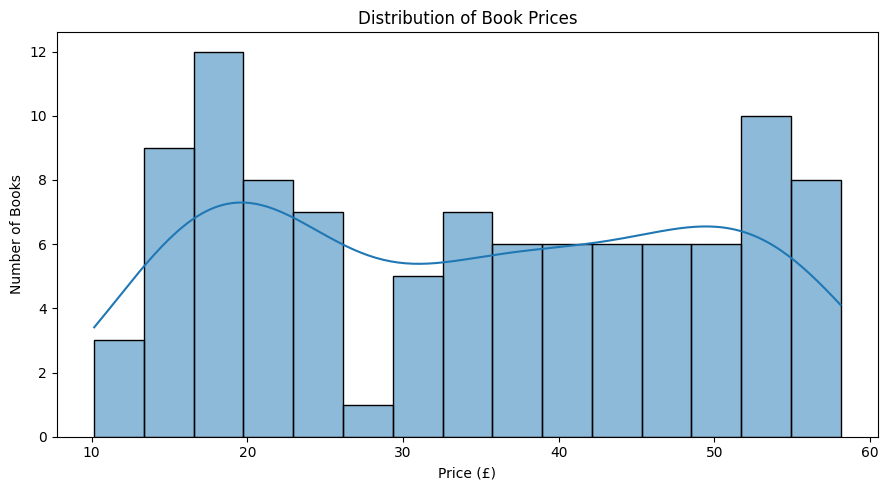

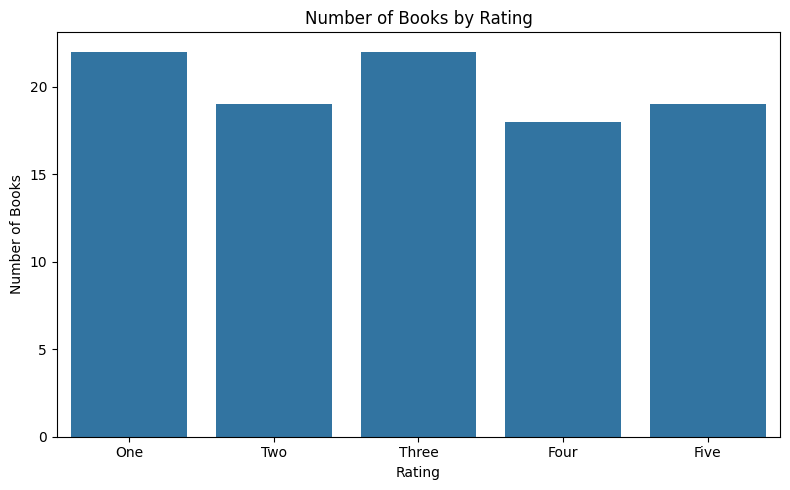

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: Distribution of book prices
plt.figure(figsize=(9, 5))
sns.histplot(clean_df["Price"], bins=15, kde=True)
plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

# Chart 2: Number of Books by Rating
plt.figure(figsize=(8, 5))
rating_order = ["One", "Two", "Three", "Four", "Five"]
rating_counts = (
    clean_df["Rating"]
    .value_counts()
    .reindex(rating_order, fill_value=0)
)

sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.title("Number of Books by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

In [14]:
# Save the final cleaned data in both formats
clean_df.to_csv("books_dataset_cleaned.csv", index=False)
clean_df.to_excel("books_dataset_cleaned.xlsx", index=False)

print("Final CSV and Excel files saved!")

Final CSV and Excel files saved!


In [15]:
from google.colab import files

files.download("books_dataset_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
%pip install openpyxl

In [18]:
from google.colab import files

clean_df.to_excel("books_dataset_cleaned.xlsx", index=False)

files.download("books_dataset_cleaned.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>